# Lab 4.01 - Bivariate Analysis of Qualitative Data


In [1]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 1 - soft-drinks


The file softdrinks.xlsx categorizes 250 randomly
selected consumers on the basis of their gender, their
age, and their preference for our brand or a competitor's brand of a low-calorie soft drink. Use a chi-square test for independence to see whether the drink
preference is independent of gender, and then whether
it is independent of age.  First make a plot

Results of the main calculations:
- age vs preference
  - χ² ≈ 3.8589  
  - p-value = 0.2771
  - We do not reject H0


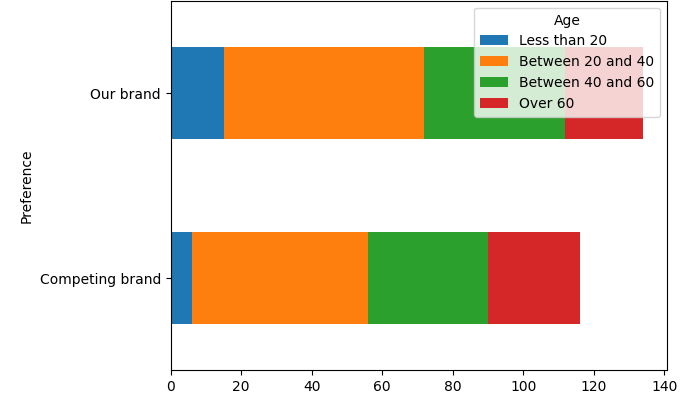



- gender vs preference
  - χ² ≈ 1.4078
  - p-value = 0.2354
  - We do not reject H0

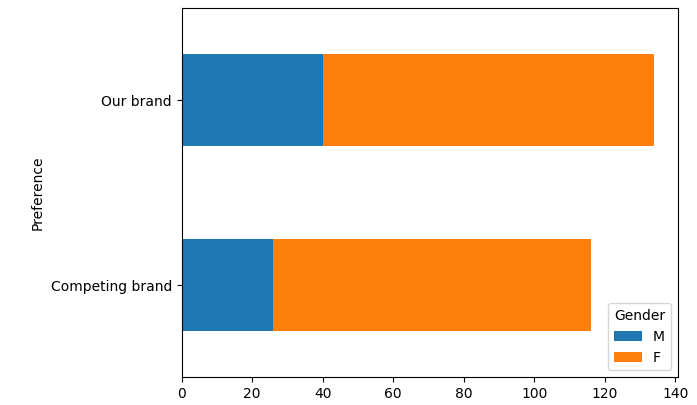

In [13]:
dataset = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Softdrinks.csv', sep=";")
dataset.head()

,Consumer,Gender,Age,Preference
0,1,F,Over 60,Our brand
1,2,F,Between 40 and 60,Our brand
2,3,M,Between 40 and 60,Our brand
3,4,F,Over 60,Competing brand
4,5,M,Between 20 and 40,Our brand


### Age vs Brand

In [7]:
# Zowel de onafh. veranderlijke als de afh. veranderlijke zijn kwalitatieve vars
# 4 cat voor Age, 2 voor Preference
# pd.crosstab(dataset['Age'], dataset['Preference'])

Preference,Competing brand,Our brand
Age,,
Between 20 and 40,50,57
Between 40 and 60,34,40
Less than 20,6,15
Over 60,26,22


In [ ]:
# Stap 1
# H0 = er is geen sign verschil in voorkeuren op basis van de leeftijd
# H1 = er is wel een sign verschil in voorkeuren op basis van de leeftijd

In [8]:
# Stap 2 - sign lvl
alpha = 0.05

In [20]:
# Stap 3 -> test stat
# Stap 4 -> p en g berekenen

observed = pd.crosstab(dataset['Preference'], dataset['Age'])
chi2, p, dof, expected = stats.chi2_contingency(observed)
g = stats.chi2.isf(alpha, df = dof)

print("Chi-squared       : %.4f" % chi2)
print("Degrees of freedom: %d" % dof)
print("P-value           : %.4f" % p)
print("Critical value    : %.4f" % g)

Chi-squared       : 3.8589
Degrees of freedom: 3
P-value           : 0.2771
Critical value    : 7.8147


In [21]:
# Stap 3: chi^2 = 3.85
# Stap 4: p = 27,71%, crit val g = 7,814
# Stap 5: conclusie
# p > 5 % dus we kunnen H0 niet rejecten
# 3,85 < g dus we kunnen H0 niet rejecten

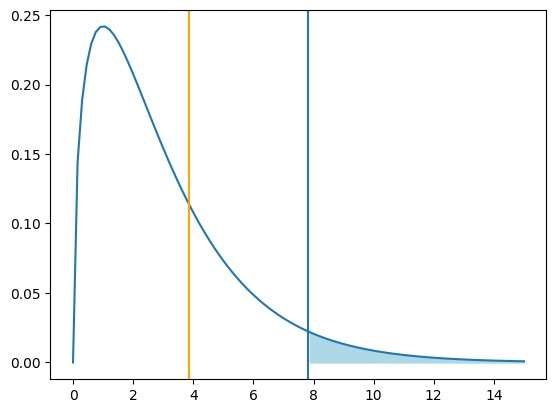

In [22]:
x = np.linspace(0, 15, num=100)
# probability density of the chi-squared distribution with degrees of freedom = dof
y = stats.chi2.pdf(x, df=dof)
# the number q for which the right tail probability is exactly 5%:
q = stats.chi2.isf(alpha, df=dof)

fig, tplot = plt.subplots(1, 1)
tplot.plot(x, y)                     # probability density
tplot.fill_between(x, y, where=x>=q, # critical area
    color='lightblue')
tplot.axvline(q)                     # critical value
tplot.axvline(chi2, color='orange')  # chi-squared

<Axes: ylabel='Preference'>

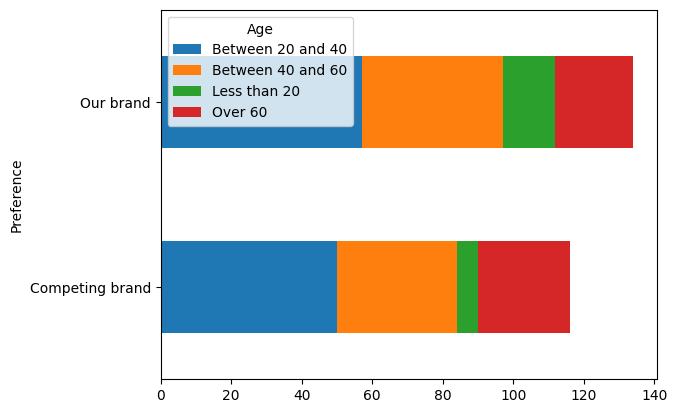

In [25]:
observed.plot(kind='barh', stacked=True)

### Gender vs Brand

In [ ]:
# Exactly the same solution

# Stap 1
# H0 = er is geen sign verschil in voorkeuren op basis van de geslacht
# H1 = er is wel een sign verschil in voorkeuren op basis van de geslacht

In [26]:
observed = pd.crosstab(dataset['Preference'], dataset['Gender'])
chi2, p, dof, expected = stats.chi2_contingency(observed)
g = stats.chi2.isf(alpha, df = dof)

print("Chi-squared       : %.4f" % chi2)
print("Degrees of freedom: %d" % dof)
print("P-value           : %.4f" % p)
print("Critical value    : %.4f" % g)

Chi-squared       : 1.4078
Degrees of freedom: 1
P-value           : 0.2354
Critical value    : 3.8415


In [ ]:
# Stap 3: chi^2 = 1.407
# Stap 4: p = 23,54%, crit val g = 3,84
# Stap 5: conclusie
# p > 5 % dus we kunnen H0 niet rejecten
# 3,85 < g dus we kunnen H0 niet rejecten

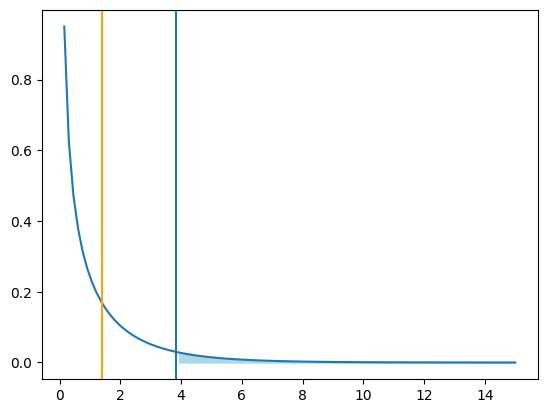

In [27]:
x = np.linspace(0, 15, num=100)
# probability density of the chi-squared distribution with degrees of freedom = dof
y = stats.chi2.pdf(x, df=dof)
# the number q for which the right tail probability is exactly 5%:
q = stats.chi2.isf(alpha, df=dof)

fig, tplot = plt.subplots(1, 1)
tplot.plot(x, y)                     # probability density
tplot.fill_between(x, y, where=x>=q, # critical area
    color='lightblue')
tplot.axvline(q)                     # critical value
tplot.axvline(chi2, color='orange')  # chi-squared

<Axes: ylabel='Preference'>

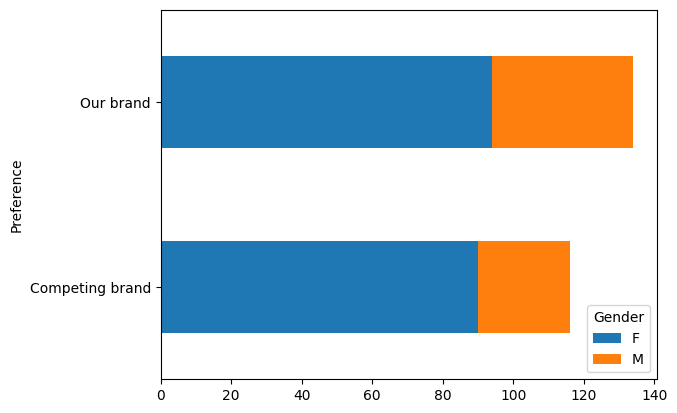

In [28]:
observed.plot(kind='barh', stacked=True)